<a href="https://colab.research.google.com/github/bvkr2005/tmdb-eda-assignment/blob/main/tmdb_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
import pandas as pd
import sqlite3

In [2]:
import requests
from google.colab import userdata

url = "https://api.themoviedb.org/3/discover/movie"

API_KEY =userdata.get('TMDB_API_KEY')

params = {
    "api_key": API_KEY,
    "language": "en-US",
    "sort_by": "popularity.desc",
    "page": 1
}

response = requests.get(url, params=params)
data = response.json()

movies = data["results"]
print(movies)

[{'adult': False, 'backdrop_path': '/1x9e0qWonw634NhIsRdvnneeqvN.jpg', 'genre_ids': [10749, 18], 'id': 1523145, 'original_language': 'en', 'original_title': 'Твоё сердце будет разбито', 'overview': 'High school student Polina is saved from bullying at her new school and makes a deal with the main bully Bars: he must pretend to be her boyfriend and protect her, and she must do everything he says. During this game, the couple develops real feelings, but her family and classmates have reasons to separate the lovers.', 'popularity': 1043.4595, 'poster_path': '/7wIBfBl2gejt6xHxNSK0reVIm7E.jpg', 'release_date': '2026-03-26', 'title': 'Your Heart Will Be Broken', 'video': False, 'vote_average': 7.174, 'vote_count': 23}, {'adult': False, 'backdrop_path': '/u8DU5fkLoM5tTRukzPC31oGPxaQ.jpg', 'genre_ids': [878, 12, 14], 'id': 83533, 'original_language': 'en', 'original_title': 'Avatar: Fire and Ash', 'overview': "In the wake of the devastating war against the RDA and the loss of their eldest son,

In [3]:
df = pd.DataFrame(movies)

df = df[[
    "id",
    "title",
    "release_date",
    "popularity",
    "vote_average",
    "vote_count",
    "genre_ids",
    "original_language"
]]

df.head(10)

,id,title,release_date,popularity,vote_average,vote_count,genre_ids,original_language
0,1523145,Your Heart Will Be Broken,2026-03-26,1043.4595,7.174,23,"[10749, 18]",en
1,83533,Avatar: Fire and Ash,2025-12-17,369.7046,7.276,2017,"[878, 12, 14]",en
2,1115544,Mike & Nick & Nick & Alice,2026-03-14,323.4594,6.760,100,"[35, 878, 80]",en
3,1290821,Shelter,2026-01-28,284.1759,6.726,434,"[28, 80, 53]",en
4,1297842,GOAT,2026-02-11,276.7612,7.760,235,"[16, 35, 10751]",en
5,1084187,Pretty Lethal,2026-03-13,304.1287,6.800,146,"[28, 53]",en
6,1198994,Send Help,2026-01-22,208.7914,7.077,735,"[27, 53, 35]",en
7,687163,Project Hail Mary,2026-03-15,256.0702,8.174,804,"[878, 12]",en
8,875828,Peaky Blinders: The Immortal Man,2026-03-05,175.0863,7.320,581,"[80, 18]",en
9,840464,Greenland 2: Migration,2026-01-07,176.0529,6.492,764,"[12, 53, 878]",en


In [4]:
import json

df["genre_ids"] = df["genre_ids"].apply(json.dumps)

In [5]:
conn = sqlite3.connect("movies.db")

df.to_sql("movies", conn, if_exists="replace", index=False)

conn.close()

Task 2 — Perform EDA

In [6]:
conn = sqlite3.connect("movies.db")

movies_df = pd.read_sql("SELECT * FROM movies", conn)

movies_df

,id,title,release_date,popularity,vote_average,vote_count,genre_ids,original_language
0,1523145,Your Heart Will Be Broken,2026-03-26,1043.4595,7.174,23,"[10749, 18]",en
1,83533,Avatar: Fire and Ash,2025-12-17,369.7046,7.276,2017,"[878, 12, 14]",en
2,1115544,Mike & Nick & Nick & Alice,2026-03-14,323.4594,6.760,100,"[35, 878, 80]",en
3,1290821,Shelter,2026-01-28,284.1759,6.726,434,"[28, 80, 53]",en
4,1297842,GOAT,2026-02-11,276.7612,7.760,235,"[16, 35, 10751]",en
5,1084187,Pretty Lethal,2026-03-13,304.1287,6.800,146,"[28, 53]",en
6,1198994,Send Help,2026-01-22,208.7914,7.077,735,"[27, 53, 35]",en
7,687163,Project Hail Mary,2026-03-15,256.0702,8.174,804,"[878, 12]",en
8,875828,Peaky Blinders: The Immortal Man,2026-03-05,175.0863,7.320,581,"[80, 18]",en
9,840464,Greenland 2: Migration,2026-01-07,176.0529,6.492,764,"[12, 53, 878]",en


In [7]:
movies_df.head()

,id,title,release_date,popularity,vote_average,vote_count,genre_ids,original_language
0,1523145,Your Heart Will Be Broken,2026-03-26,1043.4595,7.174,23,"[10749, 18]",en
1,83533,Avatar: Fire and Ash,2025-12-17,369.7046,7.276,2017,"[878, 12, 14]",en
2,1115544,Mike & Nick & Nick & Alice,2026-03-14,323.4594,6.760,100,"[35, 878, 80]",en
3,1290821,Shelter,2026-01-28,284.1759,6.726,434,"[28, 80, 53]",en
4,1297842,GOAT,2026-02-11,276.7612,7.760,235,"[16, 35, 10751]",en


In [8]:
movies_df.describe()

,id,popularity,vote_average,vote_count
count,2.000000e+01,20.000000,20.000000,20.000000
mean,1.065390e+06,236.965425,6.938400,545.000000
std,3.129020e+05,207.144710,0.822998,659.317909
min,8.353300e+04,99.379800,5.209000,2.000000
25%,8.789158e+05,116.335800,6.419000,94.500000
50%,1.137552e+06,180.563250,7.036500,291.500000
75%,1.271912e+06,278.614875,7.389500,742.250000
max,1.523145e+06,1043.459500,8.500000,2398.000000


In [9]:
movies_df.isnull().sum()

,0
id,0
title,0
release_date,0
popularity,0
vote_average,0
vote_count,0
genre_ids,0
original_language,0


In [10]:
movies_df["genre_ids"] = movies_df["genre_ids"].apply(eval)

genres_exploded = movies_df.explode("genre_ids")
genre_counts = genres_exploded["genre_ids"].value_counts()

genre_counts

,count
genre_ids,
35,7
12,6
878,6
53,6
80,5
27,5
10751,4
18,4
28,3


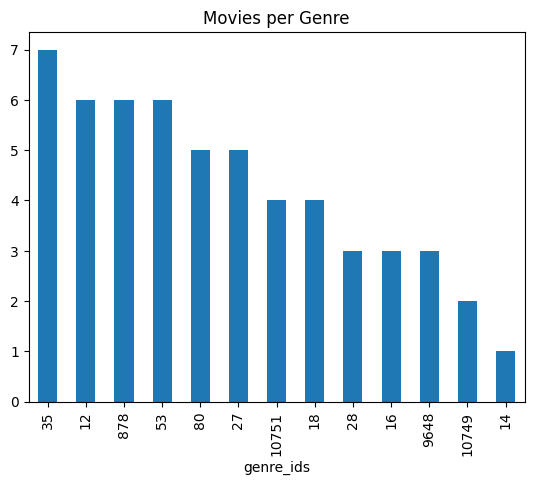

In [11]:
import matplotlib.pyplot as plt

genre_counts.plot(kind='bar')
plt.title("Movies per Genre")
plt.show()